In [2]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler

# Đọc file CSV cơ bản
df = pd.read_csv('../data/customer_features.csv')

In [3]:
df

,customer_id,total_amount,mean_amount,median_amount,max_amount,std_amount,high_value_txn_ratio,mobile_ratio,pos_ratio,web_ratio,...,distance_from_home_count,recent_distance_from_home_ratio,merchant_Education,merchant_Entertainment,merchant_Gas,merchant_Grocery,merchant_Healthcare,merchant_Restaurant,merchant_Retail,merchant_Travel
0,CUST_10000,5.090032e+07,32712.289968,998.070,4092679.04,170741.544258,0.111183,0.302057,0.095116,0.602828,...,457,0.294352,0.124679,0.129820,0.127892,0.131748,0.118252,0.125964,0.113111,0.128535
1,CUST_10018,4.779220e+07,37337.659898,1217.625,3136178.28,167407.942563,0.125000,0.064844,0.100781,0.834375,...,424,0.330894,0.121094,0.133594,0.136719,0.124219,0.114844,0.127344,0.101562,0.140625
2,CUST_10022,4.503120e+07,24553.541778,229.340,2317382.21,141098.043238,0.092148,0.050709,0.067612,0.881679,...,606,0.327518,0.132497,0.134133,0.119956,0.125409,0.130862,0.107961,0.125409,0.123773
3,CUST_10039,5.413445e+07,34436.674701,354.375,4476054.86,227587.904069,0.094148,0.053435,0.072519,0.874046,...,419,0.267495,0.124046,0.127863,0.136132,0.113232,0.108142,0.136132,0.122774,0.131679
4,CUST_10102,7.457736e+07,41339.999313,7380.220,5962927.35,276885.578742,0.094789,0.051552,0.088692,0.859756,...,407,0.224654,0.118625,0.114745,0.126940,0.138581,0.123060,0.123060,0.134146,0.120843
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4864,CUST_99937,3.131182e+07,25920.378328,549.185,1950556.88,131304.418131,0.124172,0.050497,0.066225,0.883278,...,446,0.366581,0.103477,0.128311,0.153974,0.141556,0.107616,0.127483,0.113411,0.124172
4865,CUST_99944,8.197203e+07,48247.224414,23523.040,4053938.97,178501.398280,0.530901,0.824014,0.072396,0.103590,...,408,0.239709,0.123602,0.117128,0.127722,0.128311,0.136551,0.128899,0.114185,0.123602
4866,CUST_99952,3.461989e+08,203407.089360,211833.940,5400485.23,293575.725786,0.789072,0.454759,0.088132,0.457109,...,467,0.269301,0.129847,0.125147,0.113984,0.129260,0.125147,0.125147,0.122797,0.128672
4867,CUST_99957,8.361538e+07,68369.079845,53242.560,4566321.21,176452.166108,0.767784,0.054783,0.076860,0.868357,...,326,0.267511,0.139002,0.135732,0.129191,0.117743,0.125102,0.119379,0.119379,0.114473


In [4]:
df.columns

Index(['customer_id', 'total_amount', 'mean_amount', 'median_amount',
       'max_amount', 'std_amount', 'high_value_txn_ratio', 'mobile_ratio',
       'pos_ratio', 'web_ratio', 'online_ratio', 'basic_card_ratio',
       'gold_card_ratio', 'premium_card_ratio', 'unique_card_type_count',
       'unique_countries', 'unique_cities', 'unique_currencies',
       'city_diversity', 'foreign_txn_ratio', 'top_country_ratio',
       'distance_from_home_ratio', 'distance_from_home_count',
       'recent_distance_from_home_ratio', 'merchant_Education',
       'merchant_Entertainment', 'merchant_Gas', 'merchant_Grocery',
       'merchant_Healthcare', 'merchant_Restaurant', 'merchant_Retail',
       'merchant_Travel'],
      dtype='object')

# Feature Selection for Clustering

## Feature nên đưa vào clustering

Không nên đưa tất cả feature raw vào. Nên ưu tiên các feature thể hiện **hành vi tương đối**.

### Nên đưa vào clustering:

| Feature |
|---|
| `merchant_category_ratio_*` |
| `channel_ratio_*` |
| `card_type_ratio_*` |
| `total_amount_log` |
| `mean_amount_log` |
| `max_amount_log` |
| `high_value_txn_ratio` |
| `unique_countries` |
| `unique_cities` |
| `unique_currencies` |
| `foreign_txn_ratio` |
| `top_country_ratio` |
| `city_diversity_ratio` |
| `distance_from_home_ratio` |
| `category_diversity` |
| `category_entropy` |
| `online_ratio` |

### Hạn chế đưa trực tiếp:

| Feature |
|---|
| `total_amount` |
| `mean_amount` |
| `max_amount` |
| `merchant_category_count_*` |
| `distance_from_home_count` |


> **Lý do:** Các biến raw (count, total) dễ làm cụm bị tách theo "người giao dịch nhiều hay ít", thay vì tách theo "nhu cầu sản phẩm".


In [5]:
import numpy as np
from scipy.stats import entropy

# ============================================================
# 1. MERCHANT CATEGORY RATIOS
# ============================================================
merchant_cols = [col for col in df.columns if col.startswith('merchant_')]
print("=== 1. merchant_category_ratio_* ===")
print(f"Các cột merchant gốc: {merchant_cols}")
for col in merchant_cols:
    cat_name = col.replace('merchant_', '')
    df[f'merchant_category_ratio_{cat_name}'] = df[col] / df[merchant_cols].sum(axis=1)

# Hiển thị 3 dòng đầu
ratio_cols = [col for col in df.columns if col.startswith('merchant_category_ratio_')]
display(df[merchant_cols + ratio_cols].head(3).round(4))
print("→ Mỗi dòng (customer) có tổng ratio = 1.0")

# ============================================================
# 2. CHANNEL RATIOS (đã có sẵn, đổi tên)
# ============================================================
print("\n=== 2. channel_ratio_* ===")
df['channel_ratio_mobile'] = df['mobile_ratio']
df['channel_ratio_pos']    = df['pos_ratio']
df['channel_ratio_web']    = df['web_ratio']
display(df[['mobile_ratio', 'pos_ratio', 'web_ratio',
            'channel_ratio_mobile', 'channel_ratio_pos', 'channel_ratio_web']].head(5).round(4))

# ============================================================
# 3. CARD TYPE RATIOS (đã có sẵn, đổi tên)
# ============================================================
print("\n=== 3. card_type_ratio_* ===")
df['card_type_ratio_basic']   = df['basic_card_ratio']
df['card_type_ratio_gold']    = df['gold_card_ratio']
df['card_type_ratio_premium'] = df['premium_card_ratio']
display(df[['basic_card_ratio', 'gold_card_ratio', 'premium_card_ratio',
            'card_type_ratio_basic', 'card_type_ratio_gold', 'card_type_ratio_premium']].head(5).round(4))

# ============================================================
# 4. LOG TRANSFORMS
# ============================================================
print("\n=== 4. total_amount_log, mean_amount_log, max_amount_log ===")
df['total_amount_log'] = np.log1p(df['total_amount'])
df['mean_amount_log']  = np.log1p(df['mean_amount'])
df['max_amount_log']   = np.log1p(df['max_amount'])

display(df[['total_amount', 'total_amount_log',
            'mean_amount', 'mean_amount_log',
            'max_amount', 'max_amount_log']].head(5).round(4))
print("→ Dùng log1p = log(1+x) để tránh lỗi khi giá trị = 0")

# ============================================================
# 5. CITY DIVERSITY RATIO
# ============================================================
print("\n=== 5. city_diversity_ratio ===")
print(f"city_diversity (gốc): min={df['city_diversity'].min():.4f}, max={df['city_diversity'].max():.4f}")
print(f"unique_cities:          min={df['unique_cities'].min()}, max={df['unique_cities'].max()}")
df['city_diversity_ratio'] = df['city_diversity'] / df['unique_cities']
display(df[['city_diversity', 'unique_cities', 'city_diversity_ratio']].head(5).round(4))

# ============================================================
# 6. CATEGORY DIVERSITY (Simpson)
# ============================================================
print("\n=== 6. category_diversity (Simpson's Diversity Index) ===")
df['category_diversity'] = 1 - (df[ratio_cols] ** 2).sum(axis=1)
display(df[ratio_cols + ['category_diversity']].head(5).round(4))
print("→ 0 = chỉ 1 category, ~0.875 = phân bổ đều 8 category")

# ============================================================
# 7. CATEGORY ENTROPY (Shannon)
# ============================================================
print("\n=== 7. category_entropy (Shannon Entropy) ===")
def shannon_entropy(row):
    probs = row.values + 1e-10   # tránh log(0)
    probs = probs / probs.sum()  # chuẩn hóa
    return entropy(probs)

df['category_entropy'] = df[ratio_cols].apply(shannon_entropy, axis=1)
display(df[ratio_cols + ['category_diversity', 'category_entropy']].head(5).round(4))
print("→ Entropy cao = phân phối đều, Entropy thấp = tập trung vào 1-2 category")

# ============================================================
# TỔNG KẾT
# ============================================================
print("\n" + "=" * 60)
print("TỔNG KẾT: Các cột mới đã tạo")
print("=" * 60)
new_cols = [
    *ratio_cols,
    'channel_ratio_mobile', 'channel_ratio_pos', 'channel_ratio_web',
    'card_type_ratio_basic', 'card_type_ratio_gold', 'card_type_ratio_premium',
    'total_amount_log', 'mean_amount_log', 'max_amount_log',
    'city_diversity_ratio', 'category_diversity', 'category_entropy',
]
print(f"Đã tạo {len(new_cols)} cột mới:")
for c in new_cols:
    print(f"  ✓ {c}")
print(f"\nShape hiện tại: {df.shape}")

=== 1. merchant_category_ratio_* ===
Các cột merchant gốc: ['merchant_Education', 'merchant_Entertainment', 'merchant_Gas', 'merchant_Grocery', 'merchant_Healthcare', 'merchant_Restaurant', 'merchant_Retail', 'merchant_Travel']


,merchant_Education,merchant_Entertainment,merchant_Gas,merchant_Grocery,merchant_Healthcare,merchant_Restaurant,merchant_Retail,merchant_Travel,merchant_category_ratio_Education,merchant_category_ratio_Entertainment,merchant_category_ratio_Gas,merchant_category_ratio_Grocery,merchant_category_ratio_Healthcare,merchant_category_ratio_Restaurant,merchant_category_ratio_Retail,merchant_category_ratio_Travel
0,0.1247,0.1298,0.1279,0.1317,0.1183,0.1260,0.1131,0.1285,0.1247,0.1298,0.1279,0.1317,0.1183,0.1260,0.1131,0.1285
1,0.1211,0.1336,0.1367,0.1242,0.1148,0.1273,0.1016,0.1406,0.1211,0.1336,0.1367,0.1242,0.1148,0.1273,0.1016,0.1406
2,0.1325,0.1341,0.1200,0.1254,0.1309,0.1080,0.1254,0.1238,0.1325,0.1341,0.1200,0.1254,0.1309,0.1080,0.1254,0.1238


→ Mỗi dòng (customer) có tổng ratio = 1.0

=== 2. channel_ratio_* ===


,mobile_ratio,pos_ratio,web_ratio,channel_ratio_mobile,channel_ratio_pos,channel_ratio_web
0,0.3021,0.0951,0.6028,0.3021,0.0951,0.6028
1,0.0648,0.1008,0.8344,0.0648,0.1008,0.8344
2,0.0507,0.0676,0.8817,0.0507,0.0676,0.8817
3,0.0534,0.0725,0.8740,0.0534,0.0725,0.8740
4,0.0516,0.0887,0.8598,0.0516,0.0887,0.8598



=== 3. card_type_ratio_* ===


...


=== 6. category_diversity (Simpson's Diversity Index) ===


,merchant_category_ratio_Education,merchant_category_ratio_Entertainment,merchant_category_ratio_Gas,merchant_category_ratio_Grocery,merchant_category_ratio_Healthcare,merchant_category_ratio_Restaurant,merchant_category_ratio_Retail,merchant_category_ratio_Travel,category_diversity
0,0.1247,0.1298,0.1279,0.1317,0.1183,0.1260,0.1131,0.1285,0.8747
1,0.1211,0.1336,0.1367,0.1242,0.1148,0.1273,0.1016,0.1406,0.8739
2,0.1325,0.1341,0.1200,0.1254,0.1309,0.1080,0.1254,0.1238,0.8745
3,0.1240,0.1279,0.1361,0.1132,0.1081,0.1361,0.1228,0.1317,0.8743
4,0.1186,0.1147,0.1269,0.1386,0.1231,0.1231,0.1341,0.1208,0.8746


→ 0 = chỉ 1 category, ~0.875 = phân bổ đều 8 category

=== 7. category_entropy (Shannon Entropy) ===


,merchant_category_ratio_Education,merchant_category_ratio_Entertainment,merchant_category_ratio_Gas,merchant_category_ratio_Grocery,merchant_category_ratio_Healthcare,merchant_category_ratio_Restaurant,merchant_category_ratio_Retail,merchant_category_ratio_Travel,category_diversity,category_entropy
0,0.1247,0.1298,0.1279,0.1317,0.1183,0.1260,0.1131,0.1285,0.8747,2.0783
1,0.1211,0.1336,0.1367,0.1242,0.1148,0.1273,0.1016,0.1406,0.8739,2.0748
2,0.1325,0.1341,0.1200,0.1254,0.1309,0.1080,0.1254,0.1238,0.8745,2.0774
3,0.1240,0.1279,0.1361,0.1132,0.1081,0.1361,0.1228,0.1317,0.8743,2.0765
4,0.1186,0.1147,0.1269,0.1386,0.1231,0.1231,0.1341,0.1208,0.8746,2.0777


→ Entropy cao = phân phối đều, Entropy thấp = tập trung vào 1-2 category

TỔNG KẾT: Các cột mới đã tạo
Đã tạo 20 cột mới:
  ✓ merchant_category_ratio_Education
  ✓ merchant_category_ratio_Entertainment
  ✓ merchant_category_ratio_Gas
  ✓ merchant_category_ratio_Grocery
  ✓ merchant_category_ratio_Healthcare
  ✓ merchant_category_ratio_Restaurant
  ✓ merchant_category_ratio_Retail
  ✓ merchant_category_ratio_Travel
  ✓ channel_ratio_mobile
  ✓ channel_ratio_pos
  ✓ channel_ratio_web
  ✓ card_type_ratio_basic
  ✓ card_type_ratio_gold
  ✓ card_type_ratio_premium
  ✓ total_amount_log
  ✓ mean_amount_log
  ✓ max_amount_log
  ✓ city_diversity_ratio
  ✓ category_diversity
  ✓ category_entropy

Shape hiện tại: (4869, 52)


In [6]:
df.head()

,customer_id,total_amount,mean_amount,median_amount,max_amount,std_amount,high_value_txn_ratio,mobile_ratio,pos_ratio,web_ratio,...,channel_ratio_web,card_type_ratio_basic,card_type_ratio_gold,card_type_ratio_premium,total_amount_log,mean_amount_log,max_amount_log,city_diversity_ratio,category_diversity,category_entropy
0,CUST_10000,50900323.19,32712.289968,998.070,4092679.04,170741.544258,0.111183,0.302057,0.095116,0.602828,...,0.602828,0.0,0.0,1.0,17.745380,10.395537,15.224711,0.000643,0.874722,2.078314
1,CUST_10018,47792204.67,37337.659898,1217.625,3136178.28,167407.942563,0.125000,0.064844,0.100781,0.834375,...,0.834375,0.0,0.0,1.0,17.682373,10.527785,14.958516,0.000781,0.873871,2.074822
2,CUST_10022,45031195.62,24553.541778,229.340,2317382.21,141098.043238,0.092148,0.050709,0.067612,0.881679,...,0.881679,1.0,0.0,0.0,17.622866,10.108652,14.655949,0.000545,0.874508,2.077431
3,CUST_10039,54134452.63,34436.674701,354.375,4476054.86,227587.904069,0.094148,0.053435,0.072519,0.874046,...,0.874046,0.0,0.0,1.0,17.806981,10.446906,15.314253,0.000636,0.874271,2.076483
4,CUST_10102,74577358.76,41339.999313,7380.220,5962927.35,276885.578742,0.094789,0.051552,0.088692,0.859756,...,0.859756,0.0,0.0,1.0,18.127348,10.629610,15.601072,0.000554,0.874558,2.077689


In [7]:
# ============================================================
# PHÂN TÍCH TOÀN BỘ 52 CỘT
# ============================================================
print("Danh sách toàn bộ", len(df.columns), "cột:\n")
for i, c in enumerate(df.columns, 1):
    print(f"  {i:2d}. {c}")

# ============================================================
# 1. Phân loại cột theo nhóm
# ============================================================
print("\n" + "=" * 60)
print("1. PHÂN LOẠI CỘT THEO NHÓM")
print("=" * 60)

id_cols      = [c for c in df.columns if c in ['customer_id']]
raw_amount   = [c for c in df.columns if c in ['total_amount','mean_amount','median_amount','max_amount','std_amount']]
raw_count    = [c for c in df.columns if c in ['unique_card_type_count','distance_from_home_count']]
ratio_cols_all = [c for c in df.columns if c.endswith('_ratio')]
merchant_cols = [c for c in df.columns if c.startswith('merchant_')]
unique_cols   = [c for c in df.columns if c.startswith('unique_')]
card_cols     = [c for c in df.columns if c in ['basic_card_ratio','gold_card_ratio','premium_card_ratio']]
log_cols      = [c for c in df.columns if c.endswith('_log')]
diversity_cols = [c for c in df.columns if c in ['city_diversity','city_diversity_ratio','category_diversity','category_entropy']]
other         = [c for c in df.columns if c not in (id_cols + raw_amount + raw_count + ratio_cols_all + merchant_cols + unique_cols + card_cols + log_cols + diversity_cols)]

print(f"  ID:              {id_cols}")
print(f"  Raw amount:      {raw_amount}  ← ⚠️ dễ gây lệch cụm")
print(f"  Raw count:       {raw_count}    ← ⚠️ dễ gây lệch cụm")
print(f"  Ratio:           {len(ratio_cols_all)} cột")
print(f"  Merchant:        {len(merchant_cols)} cột")
print(f"  Unique counts:   {unique_cols}")
print(f"  Card ratios:     {card_cols}")
print(f"  Log transforms:  {log_cols}")
print(f"  Diversity:       {diversity_cols}")
print(f"  Khác:            {other}")

# ============================================================
# 2. Variance toàn bộ cột numeric
# ============================================================
print("\n" + "=" * 60)
print("2. VARIANCE TOÀN BỘ CỘT NUMERIC (sau chuẩn hóa 0-1)")
print("=" * 60)

numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
numeric_cols = [c for c in numeric_cols if c != 'customer_id']

df_num = df[numeric_cols].copy()
scaler = MinMaxScaler()
df_num_scaled = pd.DataFrame(scaler.fit_transform(df_num), columns=df_num.columns)
var_all = df_num_scaled.var().sort_values()

zero_var   = [c for c, v in var_all.items() if v < 0.0001]
low_var    = [c for c, v in var_all.items() if 0.0001 <= v < 0.005]
medium_var = [c for c, v in var_all.items() if 0.005 <= v < 0.02]
high_var   = [c for c, v in var_all.items() if v >= 0.02]

print(f"\n❌ Zero variance ({len(zero_var)} cột): {zero_var}")
print(f"\n⚠️  Low variance < 0.005 ({len(low_var)} cột): {low_var}")
print(f"\n✅ Medium variance 0.005-0.02 ({len(medium_var)} cột):")
for c in medium_var:
    print(f"     {c}: {var_all[c]:.6f}")
print(f"\n🔥 High variance >= 0.02 ({len(high_var)} cột):")
for c in high_var:
    print(f"     {c}: {var_all[c]:.6f}")

# ============================================================
# 3. Tương quan cao giữa TẤT CẢ các cột
# ============================================================
print("\n" + "=" * 60)
print("3. CẶP TƯƠNG QUAN |r| > 0.90 (TRÊN TẤT CẢ CỘT)")
print("=" * 60)

corr_all = df_num.corr().abs()
pairs = []
for i in range(len(corr_all.columns)):
    for j in range(i+1, len(corr_all.columns)):
        r = corr_all.iloc[i, j]
        if r > 0.90:
            pairs.append((corr_all.columns[i], corr_all.columns[j], r))

pairs.sort(key=lambda x: -x[2])
for c1, c2, r in pairs:
    c1_flag = '← ZERO VAR' if c1 in zero_var else ''
    c2_flag = '← ZERO VAR' if c2 in zero_var else ''
    print(f"  r={r:.4f} | {c1} {c1_flag} ↔ {c2} {c2_flag}")


Danh sách toàn bộ 52 cột:

   1. customer_id
   2. total_amount
   3. mean_amount
   4. median_amount
   5. max_amount
   6. std_amount
   7. high_value_txn_ratio
   8. mobile_ratio
   9. pos_ratio
  10. web_ratio
  11. online_ratio
  12. basic_card_ratio
  13. gold_card_ratio
  14. premium_card_ratio
  15. unique_card_type_count
  16. unique_countries
  17. unique_cities
  18. unique_currencies
  19. city_diversity
  20. foreign_txn_ratio
  21. top_country_ratio
  22. distance_from_home_ratio
  23. distance_from_home_count
  24. recent_distance_from_home_ratio
  25. merchant_Education
  26. merchant_Entertainment
  27. merchant_Gas
  28. merchant_Grocery
  29. merchant_Healthcare
  30. merchant_Restaurant
  31. merchant_Retail
  32. merchant_Travel
  33. merchant_category_ratio_Education
  34. merchant_category_ratio_Entertainment
  35. merchant_category_ratio_Gas
  36. merchant_category_ratio_Grocery
  37. merchant_category_ratio_Healthcare
  38. merchant_category_ratio_Restaurant
  

# Kết luận: Chọn feature cho SVD & K-Means

## Tổng quan

52 cột → sau khi lọc còn **~20 cột** để đưa vào SVD + K-Means.

---

## ❌ Loại bỏ (32 cột)

### 1. ID (1 cột)
| Cột | Lý do |
|---|---|
| `customer_id` | Không phải feature |

### 2. Zero variance — hằng số (2 cột)
| Cột | Giá trị |
|---|---|
| `unique_countries` | Luôn = 12 |
| `unique_currencies` | Luôn = 11 |

### 3. Trùng lặp hoàn hảo r=1.0 — giữ 1, bỏ phần còn lại (12 cột bỏ)
| Giữ | Bỏ (trùng 100%) |
|---|---|
| `merchant_category_ratio_*` (8 cột ratio) | `merchant_Education`, `merchant_Entertainment`, `merchant_Gas`, `merchant_Grocery`, `merchant_Healthcare`, `merchant_Restaurant`, `merchant_Retail`, `merchant_Travel` |
| `channel_ratio_mobile` | `mobile_ratio` |
| `channel_ratio_pos` | `pos_ratio`, `online_ratio` |
| `channel_ratio_web` | `web_ratio` |
| `card_type_ratio_basic` | `basic_card_ratio` |
| `card_type_ratio_gold` | `gold_card_ratio` |
| `card_type_ratio_premium` | `premium_card_ratio` |
| `foreign_txn_ratio` | `distance_from_home_ratio` |

### 4. Trùng lặp gần hoàn hảo r ≥ 0.999 (3 cột bỏ)
| Giữ | Bỏ | r |
|---|---|---|
| `channel_ratio_mobile` | `channel_ratio_web` | 0.999 (mobile + web ≈ 1 − pos) |
| `category_diversity` | `category_entropy` | 0.999 |
| `foreign_txn_ratio` | `recent_distance_from_home_ratio` | 0.999 |

### 5. Raw amounts/counts — gây lệch cụm (7 cột bỏ)
| Cột | Lý do |
|---|---|
| `total_amount` | Raw, dễ tách cụm theo "ai giao dịch nhiều" |
| `mean_amount` | Raw, đồng thời r=0.949 với total_amount |
| `median_amount` | Raw, r=0.980 với mean_amount |
| `max_amount` | Raw, r=0.966 với max_amount_log (đã có bản log) |
| `std_amount` | Raw |
| `unique_card_type_count` | Raw count |
| `distance_from_home_count` | Raw count |

### 6. Redundant do constraint (2 cột bỏ)
| Cột | Lý do |
|---|---|
| `merchant_category_ratio_Travel` | 8 ratio tổng = 1 → rank = 7, bỏ 1 cột bất kỳ |
| `card_type_ratio_premium` | 3 card ratio tổng = 1 → rank = 2, bỏ 1 cột |

---

## ✅ GIỮ LẠI (~20 cột) — đưa vào SVD + K-Means

| # | Cột | Nhóm | Vai trò |
|---|---|---|---|
| 1 | `merchant_category_ratio_Education` | Merchant (7) | Hành vi chi tiêu theo ngành hàng |
| 2 | `merchant_category_ratio_Entertainment` | | |
| 3 | `merchant_category_ratio_Gas` | | |
| 4 | `merchant_category_ratio_Grocery` | | |
| 5 | `merchant_category_ratio_Healthcare` | | |
| 6 | `merchant_category_ratio_Restaurant` | | |
| 7 | `merchant_category_ratio_Retail` | | |
| 8 | `channel_ratio_mobile` | Kênh (2) | Hành vi theo kênh giao dịch |
| 9 | `channel_ratio_pos` | | |
| 10 | `card_type_ratio_basic` | Thẻ (2) | Phân khúc khách hàng theo loại thẻ |
| 11 | `card_type_ratio_gold` | | |
| 12 | `total_amount_log` | Log amount (3) | Quy mô khách hàng (đã chuẩn hóa) |
| 13 | `mean_amount_log` | | Giá trị trung bình giao dịch (đã chuẩn hóa) |
| 14 | `max_amount_log` | | Giao dịch lớn nhất (đã chuẩn hóa) |
| 15 | `high_value_txn_ratio` | Hành vi (4) | Tỷ lệ giao dịch giá trị cao |
| 16 | `foreign_txn_ratio` | | Tỷ lệ giao dịch nước ngoài |
| 17 | `top_country_ratio` | | Mức độ tập trung vào 1 quốc gia |
| 18 | `city_diversity_ratio` | | Độ đa dạng thành phố (đã chuẩn hóa) |
| 19 | `category_diversity` | Diversity (1) | Độ đa dạng ngành hàng |
| 20 | `unique_cities` | Khác (1) | Số thành phố duy nhất |

> **Tổng: 20 cột**, tất cả đều ở dạng **ratio hoặc log** → phản ánh **hành vi tương đối**, không bị lệch theo volume giao dịch.

---

## Tóm tắt quy tắc lọc

| Tiêu chí | Số cột bỏ |
|---|---|
| ID | 1 |
| Variance = 0 | 2 |
| Trùng r=1.0 | 12 |
| Trùng r≥0.999 | 3 |
| Raw amounts/counts | 7 |
| Redundant (tổng=1) | 2 |
| **Tổng bỏ** | **32** (52 → 20) |


In [8]:
# ============================================================
# Tạo DataFrame FINAL cho SVD + K-Means (20 cột)
# ============================================================

final_features = [
    'customer_id',
    # Merchant ratios (7/8 — bỏ Travel do tổng=1)
    'merchant_category_ratio_Education',
    'merchant_category_ratio_Entertainment',
    'merchant_category_ratio_Gas',
    'merchant_category_ratio_Grocery',
    'merchant_category_ratio_Healthcare',
    'merchant_category_ratio_Restaurant',
    'merchant_category_ratio_Retail',
    # Channel ratios (2/3 — bỏ web do r=0.999 với mobile)
    'channel_ratio_mobile',
    'channel_ratio_pos',
    # Card type ratios (2/3 — bỏ premium do tổng=1)
    'card_type_ratio_basic',
    'card_type_ratio_gold',
    # Log amounts (3)
    'total_amount_log',
    'mean_amount_log',
    'max_amount_log',
    # Behavioral ratios (4)
    'high_value_txn_ratio',
    'foreign_txn_ratio',
    'top_country_ratio',
    'city_diversity_ratio',
    # Diversity (1)
    'category_diversity',
    # Other (1)
    'unique_cities',
]

df_final = df[final_features].copy()

print(f"✅ DataFrame cuối cùng: {df_final.shape[0]} dòng × {df_final.shape[1]} cột")
print(f"✅ Missing: {df_final.isnull().sum().sum()}")
print(f"\nCác cột trong df_final:")
for i, c in enumerate(final_features, 1):
    print(f"  {i:2d}. {c}")


✅ DataFrame cuối cùng: 4869 dòng × 21 cột
✅ Missing: 0

Các cột trong df_final:
   1. customer_id
   2. merchant_category_ratio_Education
   3. merchant_category_ratio_Entertainment
   4. merchant_category_ratio_Gas
   5. merchant_category_ratio_Grocery
   6. merchant_category_ratio_Healthcare
   7. merchant_category_ratio_Restaurant
   8. merchant_category_ratio_Retail
   9. channel_ratio_mobile
  10. channel_ratio_pos
  11. card_type_ratio_basic
  12. card_type_ratio_gold
  13. total_amount_log
  14. mean_amount_log
  15. max_amount_log
  16. high_value_txn_ratio
  17. foreign_txn_ratio
  18. top_country_ratio
  19. city_diversity_ratio
  20. category_diversity
  21. unique_cities


In [9]:
df_final

,customer_id,merchant_category_ratio_Education,merchant_category_ratio_Entertainment,merchant_category_ratio_Gas,merchant_category_ratio_Grocery,merchant_category_ratio_Healthcare,merchant_category_ratio_Restaurant,merchant_category_ratio_Retail,channel_ratio_mobile,channel_ratio_pos,...,card_type_ratio_gold,total_amount_log,mean_amount_log,max_amount_log,high_value_txn_ratio,foreign_txn_ratio,top_country_ratio,city_diversity_ratio,category_diversity,unique_cities
0,CUST_10000,0.124679,0.129820,0.127892,0.131748,0.118252,0.125964,0.113111,0.302057,0.095116,...,0.0,17.745380,10.395537,15.224711,0.111183,0.293702,0.706298,0.000643,0.874722,9
1,CUST_10018,0.121094,0.133594,0.136719,0.124219,0.114844,0.127344,0.101562,0.064844,0.100781,...,0.0,17.682373,10.527785,14.958516,0.125000,0.331250,0.668750,0.000781,0.873871,11
2,CUST_10022,0.132497,0.134133,0.119956,0.125409,0.130862,0.107961,0.125409,0.050709,0.067612,...,0.0,17.622866,10.108652,14.655949,0.092148,0.330425,0.669575,0.000545,0.874508,11
3,CUST_10039,0.124046,0.127863,0.136132,0.113232,0.108142,0.136132,0.122774,0.053435,0.072519,...,0.0,17.806981,10.446906,15.314253,0.094148,0.266539,0.733461,0.000636,0.874271,9
4,CUST_10102,0.118625,0.114745,0.126940,0.138581,0.123060,0.123060,0.134146,0.051552,0.088692,...,0.0,18.127348,10.629610,15.601072,0.094789,0.225610,0.774390,0.000554,0.874558,11
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4864,CUST_99937,0.103477,0.128311,0.153974,0.141556,0.107616,0.127483,0.113411,0.050497,0.066225,...,1.0,17.259506,10.162823,14.483626,0.124172,0.369205,0.630795,0.000828,0.872969,11
4865,CUST_99944,0.123602,0.117128,0.127722,0.128311,0.136551,0.128899,0.114185,0.824014,0.072396,...,0.0,18.221889,10.784114,15.215200,0.530901,0.240141,0.759859,0.000589,0.874650,10
4866,CUST_99952,0.129847,0.125147,0.113984,0.129260,0.125147,0.125147,0.122797,0.454759,0.088132,...,1.0,19.662524,12.222970,15.502000,0.789072,0.274383,0.725617,0.000588,0.874819,10
4867,CUST_99957,0.139002,0.135732,0.129191,0.117743,0.125102,0.119379,0.119379,0.054783,0.076860,...,1.0,18.241738,11.132691,15.334219,0.767784,0.266558,0.733442,0.000818,0.874445,8


# Chuẩn hóa dữ liệu trước SVD & K-Means

## Vì sao cần scale?

`df_final` chứa các nhóm feature có **đơn vị & khoảng giá trị khác nhau**:

| Nhóm | Ví dụ | Khoảng giá trị |
|---|---|---|
| Ratio (0–1) | `merchant_category_ratio_*`, `channel_ratio_*`, `card_type_ratio_*` | 0.0 – 1.0 |
| Log-transformed | `total_amount_log`, `mean_amount_log`, `max_amount_log` | ~15 – 19 |
| Diversity | `category_diversity` | ~0.87 – 0.88 |
| Count | `unique_cities` | 3 – 11 |

Nếu không scale → log amounts (scale lớn) sẽ **áp đảo** SVD và K-Means, làm mất ý nghĩa của các ratio.

---

## Chọn phương pháp scale nào?

| Phương pháp | Công thức | Khi dùng |
|---|---|---|
| **StandardScaler** ✅ | $z = \frac{x - \mu}{\sigma}$ | **Khuyên dùng** — chuẩn cho SVD/PCA, mỗi feature đóng góp đều vào variance |
| MinMaxScaler | $x' = \frac{x - min}{max - min}$ | Khi muốn giữ nguyên khoảng [0,1], nhạy với outlier |
| RobustScaler | $x' = \frac{x - median}{IQR}$ | Khi có outlier, nhưng ở đây đã loại bỏ raw amounts rồi |

> **→ Chọn StandardScaler:** Phù hợp nhất cho pipeline SVD + K-Means vì:
> 1. SVD phân rã ma trận dựa trên variance → cần mọi feature có variance tương đương
> 2. K-Means dùng Euclidean distance → cần mọi feature cùng scale
> 3. Dữ liệu đã được làm sạch (không outlier nặng sau khi log-transform)


In [10]:
# ============================================================
# SCALE dữ liệu với StandardScaler (trừ customer_id)
# ============================================================
from sklearn.preprocessing import StandardScaler

# Tách ID và feature
feature_cols = [c for c in df_final.columns if c != 'customer_id']
X_features = df_final[feature_cols]

# Scale CHỈ các cột feature
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_features)

# Ghép lại: customer_id + scaled features
df_scaled = pd.DataFrame(X_scaled, columns=feature_cols, index=df_final.index)
df_scaled.insert(0, 'customer_id', df_final['customer_id'].values)

print("✅ Đã scale xong (customer_id giữ nguyên, KHÔNG bị scale)!")
print(f"Shape: {df_scaled.shape}")
print(f"\nKiểm tra: các cột feature có mean≈0, std≈1")
display(df_scaled[feature_cols].describe().round(4).loc[['mean', 'std']])

# So sánh trước/sau khi scale
print("\n--- Ví dụ 3 dòng đầu (customer_id giữ nguyên) ---")
display(df_scaled.head(3).round(4))


✅ Đã scale xong (customer_id giữ nguyên, KHÔNG bị scale)!
Shape: (4869, 21)

Kiểm tra: các cột feature có mean≈0, std≈1


,merchant_category_ratio_Education,merchant_category_ratio_Entertainment,merchant_category_ratio_Gas,merchant_category_ratio_Grocery,merchant_category_ratio_Healthcare,merchant_category_ratio_Restaurant,merchant_category_ratio_Retail,channel_ratio_mobile,channel_ratio_pos,card_type_ratio_basic,card_type_ratio_gold,total_amount_log,mean_amount_log,max_amount_log,high_value_txn_ratio,foreign_txn_ratio,top_country_ratio,city_diversity_ratio,category_diversity,unique_cities
mean,0.0000,0.0000,0.0000,0.0000,-0.0000,0.0000,0.0000,-0.0000,-0.0000,0.0000,-0.0000,-0.0000,-0.0000,0.0000,0.0000,0.0000,0.0000,-0.0000,0.0000,0.0000
std,1.0001,1.0001,1.0001,1.0001,1.0001,1.0001,1.0001,1.0001,1.0001,1.0001,1.0001,1.0001,1.0001,1.0001,1.0001,1.0001,1.0001,1.0001,1.0001,1.0001



--- Ví dụ 3 dòng đầu (customer_id giữ nguyên) ---


,customer_id,merchant_category_ratio_Education,merchant_category_ratio_Entertainment,merchant_category_ratio_Gas,merchant_category_ratio_Grocery,merchant_category_ratio_Healthcare,merchant_category_ratio_Restaurant,merchant_category_ratio_Retail,channel_ratio_mobile,channel_ratio_pos,...,card_type_ratio_gold,total_amount_log,mean_amount_log,max_amount_log,high_value_txn_ratio,foreign_txn_ratio,top_country_ratio,city_diversity_ratio,category_diversity,unique_cities
0,CUST_10000,-0.0054,0.5470,0.3389,0.8021,-0.7867,0.0957,-1.3668,-0.0049,0.7035,...,-0.4893,-0.1380,-0.2159,0.7210,-0.5555,-0.4685,0.4709,-0.2854,0.9094,-0.8720
1,CUST_10018,-0.4209,0.9862,1.3612,-0.0635,-1.1744,0.2547,-2.6898,-0.9210,1.1935,...,-0.4893,-0.2358,0.0065,0.2107,-0.4997,0.1493,-0.0293,0.6397,-1.4691,0.7551
2,CUST_10022,0.9006,1.0490,-0.5802,0.0733,0.6476,-1.9783,0.0421,-0.9756,-1.6751,...,-0.4893,-0.3281,-0.6983,-0.3694,-0.6323,0.1357,-0.0184,-0.9357,0.3116,0.7551


EXPLAINED VARIANCE RATIO (từng component)
  PC 1: 0.1550  (cumulative: 0.1550) ███████████████████████████████
  PC 2: 0.1170  (cumulative: 0.2720) ███████████████████████
  PC 3: 0.0795  (cumulative: 0.3515) ███████████████
  PC 4: 0.0690  (cumulative: 0.4204) █████████████
  PC 5: 0.0607  (cumulative: 0.4811) ████████████
  PC 6: 0.0594  (cumulative: 0.5406) ███████████
  PC 7: 0.0567  (cumulative: 0.5973) ███████████
  PC 8: 0.0561  (cumulative: 0.6534) ███████████
  PC 9: 0.0555  (cumulative: 0.7088) ███████████
  PC10: 0.0543  (cumulative: 0.7632) ██████████
  PC11: 0.0500  (cumulative: 0.8131) █████████ ← đạt 80%
  PC12: 0.0488  (cumulative: 0.8620) █████████
  PC13: 0.0377  (cumulative: 0.8997) ███████
  PC14: 0.0334  (cumulative: 0.9330) ██████ ← đạt 90%
  PC15: 0.0262  (cumulative: 0.9593) █████
  PC16: 0.0200  (cumulative: 0.9792) ███
  PC17: 0.0075  (cumulative: 0.9867) █
  PC18: 0.0072  (cumulative: 0.9939) █
  PC19: 0.0060  (cumulative: 1.0000) █
  PC20: 0.0000  (cumulativ

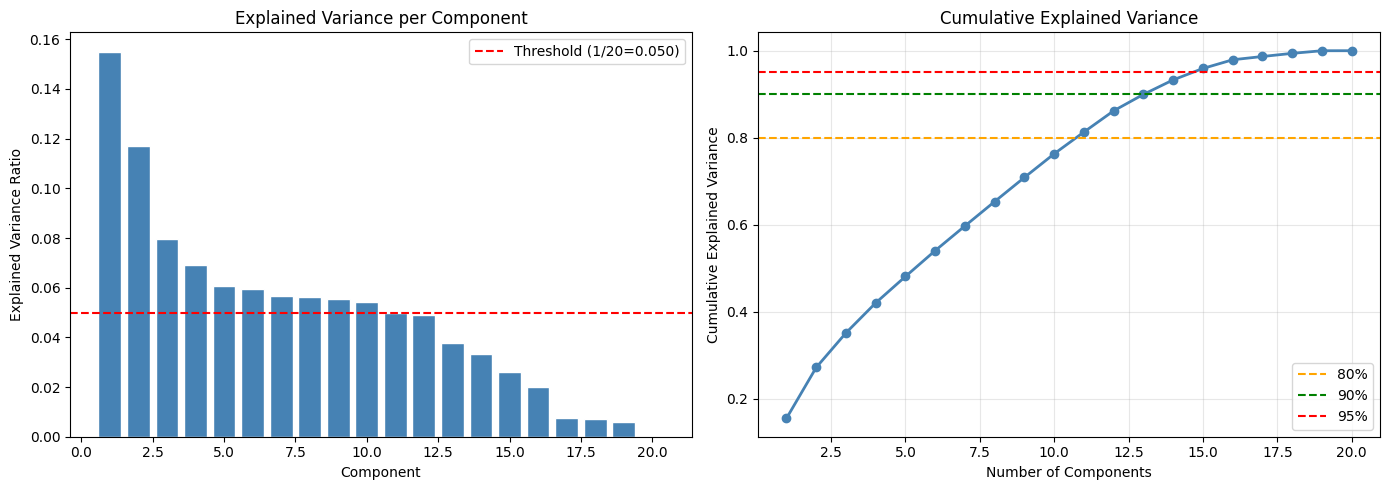


📊 Để giữ 80% variance → cần 11 components
📊 Để giữ 90% variance → cần 14 components
📊 Để giữ 95% variance → cần 15 components


In [11]:
# ============================================================
# TruncatedSVD
# ============================================================
from sklearn.decomposition import TruncatedSVD

# Dùng toàn bộ 20 components để phân tích explained variance
feature_cols = [c for c in df_scaled.columns if c not in ['customer_id', 'cluster']]
svd_full = TruncatedSVD(n_components=len(feature_cols), random_state=42)
svd_full.fit(df_scaled[feature_cols])

# Phân tích explained variance
print("=" * 60)
print("EXPLAINED VARIANCE RATIO (từng component)")
print("=" * 60)

cumsum = 0
for i, (var, cum) in enumerate(zip(
    svd_full.explained_variance_ratio_,
    svd_full.explained_variance_ratio_.cumsum()
)):
    bar = '█' * int(var * 200)
    flag = ' ← đạt 80%' if cum >= 0.80 and (cum - var) < 0.80 else ''
    flag = ' ← đạt 90%' if cum >= 0.90 and (cum - var) < 0.90 else flag
    print(f"  PC{i+1:2d}: {var:.4f}  (cumulative: {cum:.4f}) {bar}{flag}")

# Biểu đồ
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Explained variance per component
axes[0].bar(range(1, len(feature_cols)+1), svd_full.explained_variance_ratio_, color='steelblue', edgecolor='white')
axes[0].set_xlabel('Component')
axes[0].set_ylabel('Explained Variance Ratio')
axes[0].set_title('Explained Variance per Component')
axes[0].axhline(y=1/len(feature_cols), color='red', linestyle='--', label=f'Threshold (1/{len(feature_cols)}={1/len(feature_cols):.3f})')
axes[0].legend()

# Plot 2: Cumulative explained variance
axes[1].plot(range(1, len(feature_cols)+1), svd_full.explained_variance_ratio_.cumsum(), 
             marker='o', color='steelblue', linewidth=2)
axes[1].axhline(y=0.80, color='orange', linestyle='--', label='80%')
axes[1].axhline(y=0.90, color='green', linestyle='--', label='90%')
axes[1].axhline(y=0.95, color='red', linestyle='--', label='95%')
axes[1].set_xlabel('Number of Components')
axes[1].set_ylabel('Cumulative Explained Variance')
axes[1].set_title('Cumulative Explained Variance')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Tìm số components tối ưu
n_80 = (svd_full.explained_variance_ratio_.cumsum() >= 0.80).argmax() + 1
n_90 = (svd_full.explained_variance_ratio_.cumsum() >= 0.90).argmax() + 1
n_95 = (svd_full.explained_variance_ratio_.cumsum() >= 0.95).argmax() + 1
print(f"\n📊 Để giữ 80% variance → cần {n_80} components")
print(f"📊 Để giữ 90% variance → cần {n_90} components")
print(f"📊 Để giữ 95% variance → cần {n_95} components")


In [19]:
# ============================================================
# Áp dụng TruncatedSVD với n_components=16 (giữ 97.92% variance)
# ============================================================
N_COMPONENTS = 11

svd = TruncatedSVD(n_components=N_COMPONENTS, random_state=42)
X_svd = svd.fit_transform(df_scaled[feature_cols])

# Tạo DataFrame kết quả: customer_id + 11 PCs
df_svd = pd.DataFrame(
    X_svd,
    columns=[f'PC{i+1}' for i in range(N_COMPONENTS)],
    index=df_scaled.index
)
df_svd.insert(0, 'customer_id', df_scaled['customer_id'].values)

print(f"✅ TruncatedSVD hoàn tất!")
print(f"   Input:  {df_scaled[feature_cols].shape[1]} features → Output: {N_COMPONENTS} components")
print(f"   Variance giữ lại: {svd.explained_variance_ratio_.sum():.4f} ({svd.explained_variance_ratio_.sum()*100:.2f}%)")
print(f"   Shape kết quả: {df_svd.shape}")
print(f"\n--- Component loadings (top 3 features cho mỗi PC) ---")
for i in range(N_COMPONENTS):
    loadings = pd.Series(svd.components_[i], index=feature_cols)
    top_pos = loadings.nlargest(10)
    top_neg = loadings.nsmallest(10)
    print(f"\n  PC{i+1}:")
    for f, v in top_pos.items():
        print(f"     {f:45s} {v:+.4f}")
    for f, v in top_neg.items():
        print(f"     {f:45s} {v:+.4f}")

print(f"\n--- df_svd (5 dòng đầu) ---")
display(df_svd.head(5).round(4))


✅ TruncatedSVD hoàn tất!
   Input:  20 features → Output: 11 components
   Variance giữ lại: 0.8131 (81.31%)
   Shape kết quả: (4869, 12)

--- Component loadings (top 3 features cho mỗi PC) ---

  PC1:
     total_amount_log                              +0.5376
     mean_amount_log                               +0.5289
     high_value_txn_ratio                          +0.4716
     max_amount_log                                +0.2905
     card_type_ratio_gold                          +0.1291
     category_diversity                            +0.0756
     top_country_ratio                             +0.0444
     merchant_category_ratio_Entertainment         +0.0208
     merchant_category_ratio_Grocery               +0.0148
     channel_ratio_mobile                          +0.0068
     card_type_ratio_basic                         -0.2643
     city_diversity_ratio                          -0.1389
     foreign_txn_ratio                             -0.0973
     merchant_category_ratio_He

,customer_id,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,PC11
0,CUST_10000,0.1400,0.5941,-0.5100,1.0209,-0.2470,-1.2598,-0.4172,-0.0260,0.7901,1.1525,0.1167
1,CUST_10018,-0.2877,-0.0898,-0.7184,-1.1899,-0.0754,-2.6296,0.7671,-0.8249,1.7671,0.8022,-0.8104
2,CUST_10022,-1.2012,-0.7751,0.8485,1.0996,1.5656,-0.3714,0.4605,0.9739,-0.9044,0.8768,0.1858
3,CUST_10039,0.1642,1.3127,-0.7812,0.8358,-1.1744,0.3647,1.9327,-0.4170,2.1215,0.2654,-0.0752
4,CUST_10102,0.9765,0.7543,-0.5867,2.1163,-1.4206,0.1736,-0.8994,-0.3365,-1.2665,0.1547,-0.8050


  k= 2 | Inertia=68306.2 | Silhouette=0.1897
  k= 3 | Inertia=62252.0 | Silhouette=0.1147
  k= 4 | Inertia=58365.6 | Silhouette=0.1030
  k= 5 | Inertia=56230.0 | Silhouette=0.0923
  k= 6 | Inertia=54379.7 | Silhouette=0.0847
  k= 7 | Inertia=52973.9 | Silhouette=0.0777
  k= 8 | Inertia=51650.5 | Silhouette=0.0773
  k= 9 | Inertia=50502.0 | Silhouette=0.0781
  k=10 | Inertia=49523.9 | Silhouette=0.0770
  k=11 | Inertia=48723.1 | Silhouette=0.0777
  k=12 | Inertia=47889.6 | Silhouette=0.0724
  k=13 | Inertia=47235.5 | Silhouette=0.0699
  k=14 | Inertia=46768.1 | Silhouette=0.0662
  k=15 | Inertia=45896.0 | Silhouette=0.0695


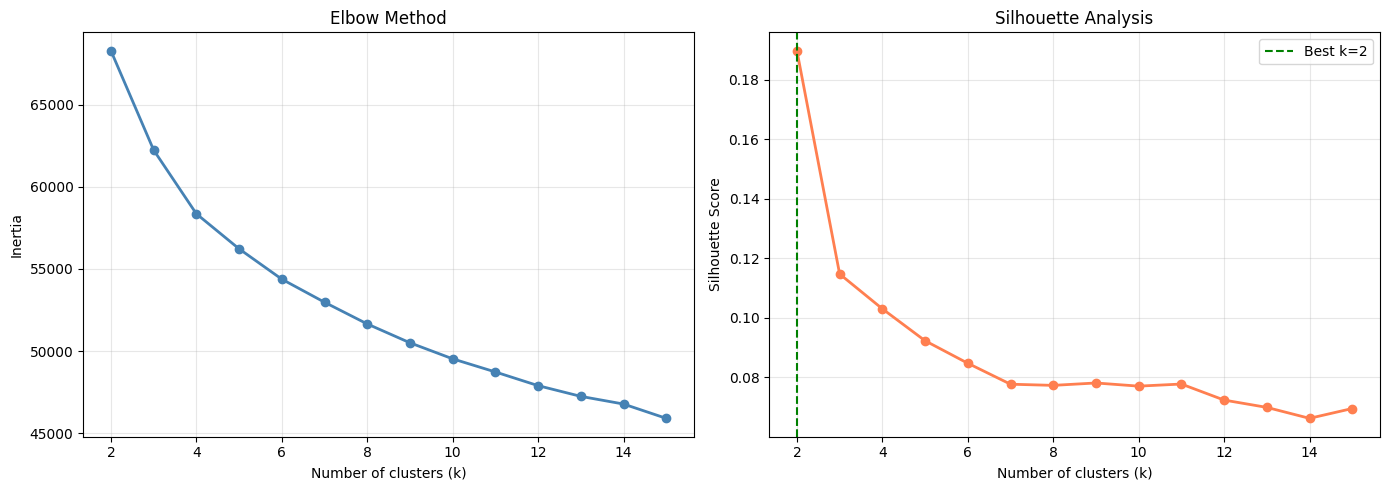


🏆 Silhouette cao nhất: k=2 (score=0.1897)


In [20]:
# ============================================================
# K-Means: Tìm số cụm tối ưu (Elbow + Silhouette)
# ============================================================
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

pc_cols = [c for c in df_svd.columns if c.startswith('PC')]
X = df_svd[pc_cols].values

# Thử k từ 2 đến 15
K_range = range(2, 16)
inertias = []
silhouettes = []

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X, labels))
    print(f"  k={k:2d} | Inertia={km.inertia_:.1f} | Silhouette={silhouettes[-1]:.4f}")

# Biểu đồ
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(K_range, inertias, marker='o', color='steelblue', linewidth=2)
axes[0].set_xlabel('Number of clusters (k)')
axes[0].set_ylabel('Inertia')
axes[0].set_title('Elbow Method')
axes[0].grid(True, alpha=0.3)

axes[1].plot(K_range, silhouettes, marker='o', color='coral', linewidth=2)
axes[1].set_xlabel('Number of clusters (k)')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Analysis')
axes[1].grid(True, alpha=0.3)

# Đánh dấu điểm tốt nhất
best_k = K_range[silhouettes.index(max(silhouettes))]
axes[1].axvline(x=best_k, color='green', linestyle='--', label=f'Best k={best_k}')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"\n🏆 Silhouette cao nhất: k={best_k} (score={max(silhouettes):.4f})")


In [21]:
# ============================================================
# Áp dụng K-Means với k=4
# ============================================================
k_final = 4
kmeans = KMeans(n_clusters=k_final, random_state=42, n_init=10)
df_svd['cluster'] = kmeans.fit_predict(X)

# Gắn nhãn cụm vào df_final và df_scaled
df_final['cluster'] = df_svd['cluster'].values
df_scaled['cluster'] = df_svd['cluster'].values

print(f"K-Means k={k_final} hoàn tất!")
print("\nPhân bố cụm:")
size_dist = df_svd['cluster'].value_counts().sort_index()
for c, s in size_dist.items():
    pct = s / len(df_svd) * 100
    bar = '█' * int(pct)
    print(f"  Cụm {c}: {s:5d} khách ({pct:5.1f}%) {bar}")

print(f"\n{'='*60}")
print("ĐẶC TRƯNG TỪNG CỤM (trên dữ liệu gốc df_final)")
print(f"{'='*60}")
feature_cols_clean = [c for c in df_final.columns if c not in ['customer_id', 'cluster']]
cluster_profile = df_final.groupby('cluster')[feature_cols_clean].mean()
display(cluster_profile.round(4))

print("\n--- Khác biệt so với trung bình toàn cục (Z-score trong cụm) ---")
global_mean = df_final[feature_cols_clean].mean()
global_std = df_final[feature_cols_clean].std()
profile_z = (cluster_profile - global_mean) / global_std

def highlight_z(val):
    if abs(val) > 1.0:
        return 'background-color: #ff6b6b; color: white'
    elif abs(val) > 0.5:
        return 'background-color: #ffd93d'
    return ''

display(profile_z.round(2).style.map(highlight_z))

K-Means k=4 hoàn tất!

Phân bố cụm:
  Cụm 0:  1328 khách ( 27.3%) ███████████████████████████
  Cụm 1:  1432 khách ( 29.4%) █████████████████████████████
  Cụm 2:   846 khách ( 17.4%) █████████████████
  Cụm 3:  1263 khách ( 25.9%) █████████████████████████

ĐẶC TRƯNG TỪNG CỤM (trên dữ liệu gốc df_final)


,merchant_category_ratio_Education,merchant_category_ratio_Entertainment,merchant_category_ratio_Gas,merchant_category_ratio_Grocery,merchant_category_ratio_Healthcare,merchant_category_ratio_Restaurant,merchant_category_ratio_Retail,channel_ratio_mobile,channel_ratio_pos,card_type_ratio_basic,card_type_ratio_gold,total_amount_log,mean_amount_log,max_amount_log,high_value_txn_ratio,foreign_txn_ratio,top_country_ratio,city_diversity_ratio,category_diversity,unique_cities
cluster,,,,,,,,,,,,,,,,,,,,
0,0.1250,0.1245,0.1257,0.1246,0.1253,0.1253,0.1252,0.3094,0.0878,0.8854,0.0011,17.4796,10.1777,14.4262,0.1514,0.3562,0.6387,0.0007,0.8744,10.5678
1,0.1247,0.1256,0.1244,0.1247,0.1252,0.1249,0.1250,0.2990,0.0863,0.0233,0.3798,17.8205,10.4493,15.1844,0.1600,0.3581,0.6273,0.0006,0.8744,10.6823
2,0.1247,0.1256,0.1251,0.1251,0.1245,0.1253,0.1246,0.3108,0.0877,0.2348,0.2137,18.9253,11.5970,14.9996,0.7260,0.2987,0.6944,0.0007,0.8744,9.9291
3,0.1245,0.1250,0.1248,0.1248,0.1254,0.1251,0.1253,0.2968,0.0864,0.4112,0.1612,17.4922,10.2536,14.8109,0.1323,0.2614,0.7386,0.0007,0.8744,8.9541



--- Khác biệt so với trung bình toàn cục (Z-score trong cụm) ---


,merchant_category_ratio_Education,merchant_category_ratio_Entertainment,merchant_category_ratio_Gas,merchant_category_ratio_Grocery,merchant_category_ratio_Healthcare,merchant_category_ratio_Restaurant,merchant_category_ratio_Retail,channel_ratio_mobile,channel_ratio_pos,card_type_ratio_basic,card_type_ratio_gold,total_amount_log,mean_amount_log,max_amount_log,high_value_txn_ratio,foreign_txn_ratio,top_country_ratio,city_diversity_ratio,category_diversity,unique_cities
cluster,,,,,,,,,,,,,,,,,,,,
0,0.030000,-0.080000,0.080000,-0.020000,0.010000,0.020000,0.020000,0.020000,0.070000,1.010000,-0.490000,-0.550000,-0.580000,-0.810000,-0.390000,0.560000,-0.430000,0.030000,-0.020000,0.400000
1,0.000000,0.050000,-0.070000,-0.010000,0.010000,-0.020000,-0.010000,-0.020000,-0.060000,-0.770000,0.480000,-0.020000,-0.130000,0.640000,-0.360000,0.590000,-0.580000,-0.260000,0.090000,0.500000
2,-0.000000,0.060000,0.020000,0.030000,-0.080000,0.020000,-0.060000,0.030000,0.060000,-0.330000,0.060000,1.690000,1.800000,0.290000,1.930000,-0.390000,0.310000,-0.080000,0.060000,-0.120000
3,-0.030000,-0.020000,-0.020000,0.010000,0.030000,-0.010000,0.030000,-0.030000,-0.050000,0.030000,-0.080000,-0.530000,-0.450000,-0.070000,-0.470000,-1.000000,0.900000,0.320000,-0.120000,-0.910000


1. SILHOUETTE SCORE TỪNG CỤM
  Cụm 0: mean=0.1064, median=0.1039, min=-0.0020, negative=0.5%, size=1328
  Cụm 1: mean=0.1139, median=0.1076, min=0.0031, negative=0.0%, size=1432
  Cụm 2: mean=0.1353, median=0.1403, min=-0.0559, negative=9.9%, size=846
  Cụm 3: mean=0.0655, median=0.0553, min=-0.0392, negative=16.6%, size=1263


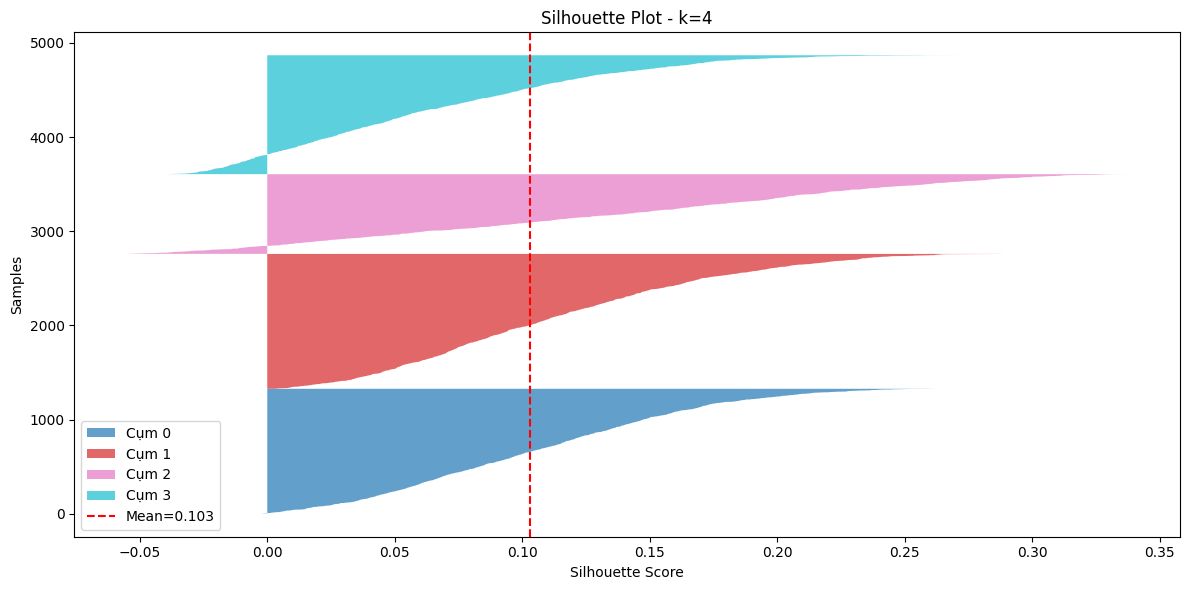


2. KHOẢNG CÁCH GIỮA CÁC TÂM CỤM (Euclidean)


,Cụm 0,Cụm 1,Cụm 2,Cụm 3
Cụm 0,0.00,2.60,4.59,2.75
Cụm 1,2.60,0.00,3.80,2.98
Cụm 2,4.59,3.80,0.00,4.17
Cụm 3,2.75,2.98,4.17,0.00


  Gần nhất: 2.60  |  Xa nhất: 4.59  |  Tỉ lệ: 0.565

3. GIÁ TRỊ THỰC TẾ (RAW) THEO CỤM - để diễn giải & đặt tên


,so_luong,tong_chi_tieu_TB,giao_dich_TB,giao_dich_max_TB,ty_le_high_value,ty_le_nuoc_ngoai,tap_trung_quoc_gia,dung_basic_card,dung_gold_card
cluster,,,,,,,,,
0,1328,"41,295,807","27,302","2,025,581",0.15,0.36,0.64,0.89,0.00
1,1432,"58,198,057","35,435","4,130,637",0.16,0.36,0.63,0.02,0.38
2,846,"198,788,007","127,259","3,585,943",0.73,0.30,0.69,0.23,0.21
3,1263,"41,410,944","29,316","3,036,911",0.13,0.26,0.74,0.41,0.16



👉 Dựa vào bảng trên để ĐẶT TÊN cho từng cụm ở cell tiếp theo.


In [22]:
# ============================================================
# PHÂN TÍCH SÂU: Đánh giá chất lượng cụm (k=4)
# ============================================================
from sklearn.metrics import silhouette_samples
import seaborn as sns

n_clusters = k_final

# --- 1. Silhouette từng cụm ---
print("=" * 60)
print("1. SILHOUETTE SCORE TỪNG CỤM")
print("=" * 60)
sample_sil = silhouette_samples(X, df_svd['cluster'])
df_svd['silhouette'] = sample_sil

for c in range(n_clusters):
    cluster_sil = sample_sil[df_svd['cluster'] == c]
    neg_pct = (cluster_sil < 0).mean() * 100
    print(f"  Cụm {c}: mean={cluster_sil.mean():.4f}, median={np.median(cluster_sil):.4f}, "
          f"min={cluster_sil.min():.4f}, negative={neg_pct:.1f}%, size={len(cluster_sil)}")

# Biểu đồ silhouette
fig, ax = plt.subplots(figsize=(12, 6))
y_lower = 0
colors = plt.cm.tab10(np.linspace(0, 1, n_clusters))
for c in range(n_clusters):
    cluster_sil = np.sort(sample_sil[df_svd['cluster'] == c])
    y_upper = y_lower + len(cluster_sil)
    ax.fill_betweenx(np.arange(y_lower, y_upper), 0, cluster_sil,
                     facecolor=colors[c], alpha=0.7, label=f'Cụm {c}')
    y_lower = y_upper
ax.axvline(x=sample_sil.mean(), color='red', linestyle='--', label=f'Mean={sample_sil.mean():.3f}')
ax.set_xlabel('Silhouette Score')
ax.set_ylabel('Samples')
ax.set_title(f'Silhouette Plot - k={n_clusters}')
ax.legend(loc='lower left')
plt.tight_layout()
plt.show()

# --- 2. Khoảng cách giữa các tâm cụm ---
print("\n" + "=" * 60)
print("2. KHOẢNG CÁCH GIỮA CÁC TÂM CỤM (Euclidean)")
print("=" * 60)
centers = kmeans.cluster_centers_
dist_matrix = np.zeros((n_clusters, n_clusters))
for i in range(n_clusters):
    for j in range(i + 1, n_clusters):
        dist_matrix[i][j] = np.linalg.norm(centers[i] - centers[j])
        dist_matrix[j][i] = dist_matrix[i][j]

dist_df = pd.DataFrame(
    dist_matrix,
    columns=[f'Cụm {i}' for i in range(n_clusters)],
    index=[f'Cụm {i}' for i in range(n_clusters)]
)
display(dist_df.round(2))

triu = dist_matrix[np.triu_indices(n_clusters, k=1)]
closest = triu.min()
farthest = triu.max()
print(f"  Gần nhất: {closest:.2f}  |  Xa nhất: {farthest:.2f}  |  Tỉ lệ: {closest/farthest:.3f}")

# --- 3. Bảng tổng quan kinh doanh (RAW values) ---
print("\n" + "=" * 60)
print("3. GIÁ TRỊ THỰC TẾ (RAW) THEO CỤM - để diễn giải & đặt tên")
print("=" * 60)
raw_stats = df_final.copy()
raw_stats['total_amount'] = df['total_amount']
raw_stats['mean_amount'] = df['mean_amount']
raw_stats['max_amount'] = df['max_amount']

cluster_summary = raw_stats.groupby('cluster').agg(
    so_luong=('customer_id', 'count'),
    tong_chi_tieu_TB=('total_amount', 'mean'),
    giao_dich_TB=('mean_amount', 'mean'),
    giao_dich_max_TB=('max_amount', 'mean'),
    ty_le_high_value=('high_value_txn_ratio', 'mean'),
    ty_le_nuoc_ngoai=('foreign_txn_ratio', 'mean'),
    tap_trung_quoc_gia=('top_country_ratio', 'mean'),
    dung_basic_card=('card_type_ratio_basic', 'mean'),
    dung_gold_card=('card_type_ratio_gold', 'mean'),
).round(2)
cluster_summary['tong_chi_tieu_TB'] = cluster_summary['tong_chi_tieu_TB'].apply(lambda x: f'{x:,.0f}')
cluster_summary['giao_dich_TB'] = cluster_summary['giao_dich_TB'].apply(lambda x: f'{x:,.0f}')
cluster_summary['giao_dich_max_TB'] = cluster_summary['giao_dich_max_TB'].apply(lambda x: f'{x:,.0f}')

display(cluster_summary)

print("\n👉 Dựa vào bảng trên để ĐẶT TÊN cho từng cụm ở cell tiếp theo.")

In [23]:
# ============================================================
# 🏷️ PHÂN KHÚC KHÁCH HÀNG (chỉ để dán nhãn, KHÔNG quyết định sản phẩm)
# ============================================================
# ⚠️ Cluster label chỉ dùng làm ngữ cảnh cho LLM prompt.
# Ranking thật nằm ở cell Personal Scoring bên dưới.

cluster_names = {
    0: 'Basic - Phổ thông (89% basic card, chi tiêu thấp ~41M, có giao dịch nước ngoài)',
    1: 'Gold - Du lịch (38% gold card, max GD cao ~4.1M, hay đi nước ngoài, nhiều TP)',
    2: 'Siêu VIP (tổng chi tiêu ~199M gấp 3-5 lần, 73% high-value, GD TB ~127K)',
    3: 'Đại chúng nội địa (26% nước ngoài thấp nhất, tập trung 1 quốc gia 74%, chi tiêu thấp ~41M)',
}

# --- In lại Z-score profile để kiểm tra ---
feature_cols_clean = [c for c in df_final.columns if c not in ['customer_id', 'cluster']]
cluster_profile = df_final.groupby('cluster')[feature_cols_clean].mean()
global_mean = df_final[feature_cols_clean].mean()
global_std = df_final[feature_cols_clean].std()
profile_z = (cluster_profile - global_mean) / global_std

print("=" * 60)
print("ĐẶC TRƯNG TỪNG CỤM (Z-score) — xác nhận tên đã đặt")
print("=" * 60)
print("🔴 = |Z|>1   🟡 = |Z|>0.5")

def highlight_z(val):
    if abs(val) > 1.0:
        return 'background-color: #ff6b6b; color: white'
    elif abs(val) > 0.5:
        return 'background-color: #ffd93d'
    return ''

display(profile_z.round(2).style.map(highlight_z))

ĐẶC TRƯNG TỪNG CỤM (Z-score) — xác nhận tên đã đặt
🔴 = |Z|>1   🟡 = |Z|>0.5


,merchant_category_ratio_Education,merchant_category_ratio_Entertainment,merchant_category_ratio_Gas,merchant_category_ratio_Grocery,merchant_category_ratio_Healthcare,merchant_category_ratio_Restaurant,merchant_category_ratio_Retail,channel_ratio_mobile,channel_ratio_pos,card_type_ratio_basic,card_type_ratio_gold,total_amount_log,mean_amount_log,max_amount_log,high_value_txn_ratio,foreign_txn_ratio,top_country_ratio,city_diversity_ratio,category_diversity,unique_cities
cluster,,,,,,,,,,,,,,,,,,,,
0,0.030000,-0.080000,0.080000,-0.020000,0.010000,0.020000,0.020000,0.020000,0.070000,1.010000,-0.490000,-0.550000,-0.580000,-0.810000,-0.390000,0.560000,-0.430000,0.030000,-0.020000,0.400000
1,0.000000,0.050000,-0.070000,-0.010000,0.010000,-0.020000,-0.010000,-0.020000,-0.060000,-0.770000,0.480000,-0.020000,-0.130000,0.640000,-0.360000,0.590000,-0.580000,-0.260000,0.090000,0.500000
2,-0.000000,0.060000,0.020000,0.030000,-0.080000,0.020000,-0.060000,0.030000,0.060000,-0.330000,0.060000,1.690000,1.800000,0.290000,1.930000,-0.390000,0.310000,-0.080000,0.060000,-0.120000
3,-0.030000,-0.020000,-0.020000,0.010000,0.030000,-0.010000,0.030000,-0.030000,-0.050000,0.030000,-0.080000,-0.530000,-0.450000,-0.070000,-0.470000,-1.000000,0.900000,0.320000,-0.120000,-0.910000


In [17]:
df_final.head()

,customer_id,merchant_category_ratio_Education,merchant_category_ratio_Entertainment,merchant_category_ratio_Gas,merchant_category_ratio_Grocery,merchant_category_ratio_Healthcare,merchant_category_ratio_Restaurant,merchant_category_ratio_Retail,channel_ratio_mobile,channel_ratio_pos,...,total_amount_log,mean_amount_log,max_amount_log,high_value_txn_ratio,foreign_txn_ratio,top_country_ratio,city_diversity_ratio,category_diversity,unique_cities,cluster
0,CUST_10000,0.124679,0.129820,0.127892,0.131748,0.118252,0.125964,0.113111,0.302057,0.095116,...,17.745380,10.395537,15.224711,0.111183,0.293702,0.706298,0.000643,0.874722,9,3
1,CUST_10018,0.121094,0.133594,0.136719,0.124219,0.114844,0.127344,0.101562,0.064844,0.100781,...,17.682373,10.527785,14.958516,0.125000,0.331250,0.668750,0.000781,0.873871,11,1
2,CUST_10022,0.132497,0.134133,0.119956,0.125409,0.130862,0.107961,0.125409,0.050709,0.067612,...,17.622866,10.108652,14.655949,0.092148,0.330425,0.669575,0.000545,0.874508,11,0
3,CUST_10039,0.124046,0.127863,0.136132,0.113232,0.108142,0.136132,0.122774,0.053435,0.072519,...,17.806981,10.446906,15.314253,0.094148,0.266539,0.733461,0.000636,0.874271,9,3
4,CUST_10102,0.118625,0.114745,0.126940,0.138581,0.123060,0.123060,0.134146,0.051552,0.088692,...,18.127348,10.629610,15.601072,0.094789,0.225610,0.774390,0.000554,0.874558,11,3


In [18]:
# ============================================================
# BẢNG PHÂN KHÚC KHÁCH HÀNG (cluster info table)
# ============================================================

def parse_cluster_info(cluster_names):
    """Parse cluster_names dict thành DataFrame với các cột: cluster, cluster_name, describe."""
    rows = []
    for c, text in sorted(cluster_names.items()):
        # Tách tên và mô tả: 'Basic - Phổ thông (89% basic card...)'
        if '(' in text and text.endswith(')'):
            name = text[:text.index('(')].strip()
            desc = text[text.index('(')+1:-1].strip()
        else:
            name = text
            desc = ''
        rows.append({'cluster': c, 'cluster_name': name, 'describe': desc})
    return pd.DataFrame(rows)

df_clusters = parse_cluster_info(cluster_names)
print("📋 BẢNG PHÂN KHÚC KHÁCH HÀNG")
print("=" * 80)
display(df_clusters)

📋 BẢNG PHÂN KHÚC KHÁCH HÀNG


,cluster,cluster_name,describe
0,0,Basic - Phổ thông,"89% basic card, chi tiêu thấp ~41M, có giao dị..."
1,1,Gold - Du lịch,"38% gold card, max GD cao ~4.1M, hay đi nước n..."
2,2,Siêu VIP,"tổng chi tiêu ~199M gấp 3-5 lần, 73% high-valu..."
3,3,Đại chúng nội địa,"26% nước ngoài thấp nhất, tập trung 1 quốc gia..."
